## Data Pre-Processing

In [1]:
# IMPORT LIBRARIES

# matplotlib.pyplot
# Used to create figures and plots (maps, time series, bar charts).
import matplotlib.pyplot as plt

# natsort.natsorted
# Sorts file names in a friendly way (e.g., file1, file2, file10 instead of file1, file10, file2).
from natsort import natsorted

# collections.defaultdict
# Dictionary that automatically creates empty entries when new keys are used (useful for grouping files).
from collections import defaultdict

# cartopy.crs
# Defines coordinate reference systems for mapping (e.g., latitude–longitude projections).
import cartopy.crs as ccrs

# cartopy.feature
# Adds geographic features to maps such as coastlines, land, borders, and oceans.
import cartopy.feature as cfeature

# xarray
# Main library used to read, process, and analyze NetCDF datasets.
import xarray as xr

# pandas
# Provides powerful data structures (DataFrames) for handling time series and tabular data.
import pandas as pd

# numpy
# Core numerical library for working with arrays and performing mathematical operations.
import numpy as np

# netCDF4
# Interface to read and write NetCDF files using the NetCDF C libraries.
import netCDF4

# h5netcdf
# Alternative backend for reading NetCDF files based on HDF5 (often faster and more stable).
import h5netcdf

# h5py
# Python interface to the HDF5 binary file format used internally by many NetCDF files.
import h5py

# glob
# Finds files in folders using pattern matching (e.g., selecting all .nc files).
import glob

# sys
# Provides access to Python system functions such as environment settings and command-line arguments.
import sys

# os
# Allows interaction with the operating system (creating folders, handling file paths).
import os

# os.path
# Tools for manipulating file paths in a platform-independent way.
import os.path as op

# re
# Regular expressions library used for searching and manipulating text patterns.
import re

C:\Users\anapa\anaconda3\envs\MARS3888\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


### Combine NC files

In [2]:
# DEFINE PATHS
# -------------------------------------------------------------------
# Input Folder
# -------------------------------------------------------------------
# EXAMPLE: input_dir = r'X:\02_Modeled_Data\01_SST_DHW\02_NOAA_Coral_Watch\DHW/'
input_dir = 'sample_files'

# -------------------------------------------------------------------
# Output Folder
# -------------------------------------------------------------------
# EXAMPLE: ouput_dir = r'X:\02_Modeled_Data\01_SST_DHW\02_NOAA_Coral_Watch\combined_bymonth_DHW/'
output_dir = 'sample_files'

In [3]:
# READ NC FILES
# -------------------------------------------------------------------
# Find all NetCDF files in the input folder
# -------------------------------------------------------------------
data_files = natsorted(glob.glob(os.path.join(input_dir, "ct5km_dhw_v3.1_*.nc")))

# Check that files were found
if not data_files:
    raise FileNotFoundError("No NetCDF files were found in the input folder.")

print(f"Number of files found: {len(data_files)}")
print(f"First file: {os.path.basename(data_files[0])}")

# -------------------------------------------------------------------
# Open the first file to inspect its contents
# -------------------------------------------------------------------
ds = xr.open_dataset(data_files[0], engine="netcdf4", decode_cf=True)

# -------------------------------------------------------------------
# Print the names of all variables in the file
# -------------------------------------------------------------------
print("\nVariables in the NetCDF file:")
print(list(ds.variables))

# -------------------------------------------------------------------
# Display a summary of the dataset
# -------------------------------------------------------------------
print("\nDataset summary:")
print(ds)

# -------------------------------------------------------------------
# Show the dataset dimensions
# -------------------------------------------------------------------
print("\nDataset dimensions:")
print(ds.dims)

# -------------------------------------------------------------------
# Print each variable name and its attributes
# -------------------------------------------------------------------
print("\nVariable attributes:")
for var_name in ds.variables:
    print(f"\n{var_name}")
    print(ds[var_name].attrs)

# Close the file after inspection
ds.close()

Number of files found: 7
First file: ct5km_dhw_v3.1_20240206.nc

Variables in the NetCDF file:
['degree_heating_week', 'mask', 'crs', 'time', 'lat', 'lon']

Dataset summary:
<xarray.Dataset> Size: 311MB
Dimensions:              (time: 1, lat: 3600, lon: 7200)
Coordinates:
  * time                 (time) datetime64[ns] 8B 2024-02-06T12:00:00
  * lat                  (lat) float32 14kB 89.97 89.93 89.88 ... -89.93 -89.97
  * lon                  (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
Data variables:
    degree_heating_week  (time, lat, lon) float64 207MB ...
    mask                 (time, lat, lon) float32 104MB ...
    crs                  int16 2B ...
Attributes: (12/58)
    acknowledgement:            NOAA Coral Reef Watch Program
    cdm_data_type:              Grid
    comment:                    This is a product of the NOAA Coral Reef Watc...
    contributor_name:           NOAA Coral Reef Watch Program
    contributor_role:           Collecting source data and d

In [4]:
# COMBINE FILES

# --------------------------------------------------
# Find files
# --------------------------------------------------
data_files = natsorted(glob.glob(os.path.join(input_dir, "ct5km_dhw_v3.1_*.nc")))

if not data_files:
    raise FileNotFoundError("No NetCDF files found.")

os.makedirs(output_dir, exist_ok=True)

# --------------------------------------------------
# Group file paths by year and month
# --------------------------------------------------
files_by_month = defaultdict(list)
bad_files = []

for nc_file in data_files:
    try:
        with xr.open_dataset(nc_file, engine="h5netcdf", decode_cf=True) as ds:
            first_time = pd.to_datetime(ds["time"].values[0])
            ym_key = (first_time.year, first_time.month)
            files_by_month[ym_key].append(nc_file)
    except Exception as e:
        print(f"Skipping unreadable file: {os.path.basename(nc_file)}")
        bad_files.append(nc_file)

# --------------------------------------------------
# Combine files month by month
# --------------------------------------------------
for (year, month), monthly_files in sorted(files_by_month.items()):
    print(f"Combining {year}-{month:02d} ({len(monthly_files)} files)")

    ds_list = []
    for f in monthly_files:
        try:
            ds = xr.open_dataset(f, engine="h5netcdf", decode_cf=True)
            ds_list.append(ds)
        except Exception:
            print(f"Skipped during combine: {os.path.basename(f)}")

    if not ds_list:
        print(f"No readable files for {year}-{month:02d}")
        continue

    combined = xr.concat(ds_list, dim="time")
    combined = combined.sortby("time")

    output_file = os.path.join(output_dir, f"combined_{year}_{month:02d}.nc")
    combined.to_netcdf(output_file)

    combined.close()
    for ds in ds_list:
        ds.close()

    print(f"Saved: {output_file}")

print("\nDone.")
print(f"Unreadable files skipped: {len(bad_files)}")

Skipping unreadable file: ct5km_dhw_v3.1_20240207.nc
Combining 2024-02 (6 files)


C:\Users\anapa\AppData\Local\Temp\ipykernel_17912\1819752673.py:47: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  combined = xr.concat(ds_list, dim="time")


Saved: sample_files\combined_2024_02.nc

Done.
Unreadable files skipped: 1


In [5]:
# READ COMBINED FILE
# ---------------------------------------------------------
# Find all combined NetCDF files
# ---------------------------------------------------------
output_files = natsorted(glob.glob(op.join(output_dir, "combined_*.nc")))

if not output_files:
    raise FileNotFoundError("No combined NetCDF files were found.")

# Select the most recent file (last one in the sorted list)
file_to_check = output_files[-1]

print(f"Opening file:\n{file_to_check}")

# ---------------------------------------------------------
# Open the dataset
# ---------------------------------------------------------
with xr.open_dataset(file_to_check, engine="h5netcdf", decode_cf=True) as out_data:

    # -----------------------------------------------------
    # List all variables in the dataset
    # -----------------------------------------------------
    print("\nVariables in the NetCDF file:")
    print(list(out_data.variables))

    # -----------------------------------------------------
    # Show a summary of the dataset structure
    # -----------------------------------------------------
    print("\nDataset summary:")
    print(out_data)

    # -----------------------------------------------------
    # Display dataset dimensions
    # -----------------------------------------------------
    print("\nDataset dimensions:")
    print(out_data.dims)

    # -----------------------------------------------------
    # Check the time range in the dataset
    # -----------------------------------------------------
    if "time" in out_data.coords:
        start_time = out_data["time"].values[0]
        end_time = out_data["time"].values[-1]

        print("\nTime range in this file:")
        print(f"{start_time}  →  {end_time}")

    # -----------------------------------------------------
    # Print variable attributes (metadata)
    # -----------------------------------------------------
    print("\nVariable metadata:")
    for var_name in out_data.variables:
        print(f"\n{var_name}")
        print(out_data[var_name].attrs)

Opening file:
sample_files\combined_2024_02_GBR_degree_heating_week.nc

Variables in the NetCDF file:
['degree_heating_week', 'time', 'lat', 'lon']

Dataset summary:
<xarray.Dataset> Size: 4MB
Dimensions:              (time: 6, lat: 310, lon: 300)
Coordinates:
  * time                 (time) datetime64[ns] 48B 2024-02-06T12:00:00 ... 20...
  * lat                  (lat) float32 1kB -9.025 -9.075 ... -24.42 -24.48
  * lon                  (lon) float32 1kB 142.0 142.1 142.1 ... 156.9 157.0
Data variables:
    degree_heating_week  (time, lat, lon) float64 4MB ...
Attributes: (12/58)
    acknowledgement:            NOAA Coral Reef Watch Program
    cdm_data_type:              Grid
    comment:                    This is a product of the NOAA Coral Reef Watc...
    contributor_name:           NOAA Coral Reef Watch Program
    contributor_role:           Collecting source data and deriving products;...
    Conventions:                CF-1.6, ACDD-1.3
    ...                         ...
    

### Clip Interest Region

In [6]:
# DEFINE PATHS
# -------------------------------------------------------------------
# Input Folder
# -------------------------------------------------------------------
# EXAMPLE: input_dir = r'X:\02_Modeled_Data\01_SST_DHW\02_NOAA_Coral_Watch\combined_bymonth_DHW/'
input_dir = 'sample_files'

# -------------------------------------------------------------------
# Output Folder
# -------------------------------------------------------------------
# EXAMPLE: ouput_dir = r'X:\02_Modeled_Data\01_SST_DHW\02_NOAA_Coral_Watch\GBR_combined_bymonth_DHW/'
output_dir = 'sample_files'

In [7]:
# READ COMBINED FILE
# ---------------------------------------------------------
# Find all combined NetCDF files
# ---------------------------------------------------------
output_files = natsorted(glob.glob(op.join(output_dir, "combined_*.nc")))

if not output_files:
    raise FileNotFoundError("No combined NetCDF files were found.")

# Select the most recent file (last one in the sorted list)
file_to_check = output_files[-1]

print(f"Opening file:\n{file_to_check}")

# ---------------------------------------------------------
# Open the dataset
# ---------------------------------------------------------
with xr.open_dataset(file_to_check, engine="h5netcdf", decode_cf=True) as out_data:

    # -----------------------------------------------------
    # List all variables in the dataset
    # -----------------------------------------------------
    print("\nVariables in the NetCDF file:")
    print(list(out_data.variables))

    # -----------------------------------------------------
    # Show a summary of the dataset structure
    # -----------------------------------------------------
    print("\nDataset summary:")
    print(out_data)

    # -----------------------------------------------------
    # Display dataset dimensions
    # -----------------------------------------------------
    print("\nDataset dimensions:")
    print(out_data.dims)

    # -----------------------------------------------------
    # Check the time range in the dataset
    # -----------------------------------------------------
    if "time" in out_data.coords:
        start_time = out_data["time"].values[0]
        end_time = out_data["time"].values[-1]

        print("\nTime range in this file:")
        print(f"{start_time}  →  {end_time}")

    # -----------------------------------------------------
    # Print variable attributes (metadata)
    # -----------------------------------------------------
    print("\nVariable metadata:")
    for var_name in out_data.variables:
        print(f"\n{var_name}")
        print(out_data[var_name].attrs)

Opening file:
sample_files\combined_2024_02_GBR_degree_heating_week.nc

Variables in the NetCDF file:
['degree_heating_week', 'time', 'lat', 'lon']

Dataset summary:
<xarray.Dataset> Size: 4MB
Dimensions:              (time: 6, lat: 310, lon: 300)
Coordinates:
  * time                 (time) datetime64[ns] 48B 2024-02-06T12:00:00 ... 20...
  * lat                  (lat) float32 1kB -9.025 -9.075 ... -24.42 -24.48
  * lon                  (lon) float32 1kB 142.0 142.1 142.1 ... 156.9 157.0
Data variables:
    degree_heating_week  (time, lat, lon) float64 4MB ...
Attributes: (12/58)
    acknowledgement:            NOAA Coral Reef Watch Program
    cdm_data_type:              Grid
    comment:                    This is a product of the NOAA Coral Reef Watc...
    contributor_name:           NOAA Coral Reef Watch Program
    contributor_role:           Collecting source data and deriving products;...
    Conventions:                CF-1.6, ACDD-1.3
    ...                         ...
    

In [8]:
# CLIPPING

# ---------------------------------------------------------
# Define the clipping region
# ---------------------------------------------------------
lat_min, lat_max = -24.5, -9
lon_min, lon_max = 142, 157

region_name = "GBR"
variable_name = "degree_heating_week"

# Create output folder if it does not exist
os.makedirs(output_dir, exist_ok=True)

# ---------------------------------------------------------
# Loop through each NetCDF file
# ---------------------------------------------------------
for file in output_files:
    original_filename = os.path.basename(file)
    filename_without_ext = os.path.splitext(original_filename)[0]
    new_filename = f"{filename_without_ext}_{region_name}_{variable_name}.nc"
    output_file = os.path.join(output_dir, new_filename)

    # Skip file if already processed
    if os.path.exists(output_file):
        print(f"Skipping {original_filename} - already processed")
        continue

    print(f"Processing: {original_filename}")

    # -----------------------------------------------------
    # Open dataset
    # -----------------------------------------------------
    with xr.open_dataset(file, engine="h5netcdf", decode_cf=True) as ds:

        # -------------------------------------------------
        # Detect coordinate names
        # -------------------------------------------------
        if "lat" in ds.coords:
            lat_name = "lat"
        elif "latitude" in ds.coords:
            lat_name = "latitude"
        else:
            raise ValueError(f"No latitude coordinate found in {original_filename}")

        if "lon" in ds.coords:
            lon_name = "lon"
        elif "longitude" in ds.coords:
            lon_name = "longitude"
        else:
            raise ValueError(f"No longitude coordinate found in {original_filename}")

        # -------------------------------------------------
        # Check whether latitude is ascending or descending
        # -------------------------------------------------
        lat_values = ds[lat_name].values
        lat_ascending = lat_values[1] > lat_values[0]

        if lat_ascending:
            lat_slice = slice(lat_min, lat_max)
        else:
            lat_slice = slice(lat_max, lat_min)

        lon_slice = slice(lon_min, lon_max)

        # -------------------------------------------------
        # Clip dataset to region
        # -------------------------------------------------
        clipped_ds = ds.sel({lat_name: lat_slice, lon_name: lon_slice})

        # Keep only the target variable if desired
        if variable_name in clipped_ds.data_vars:
            clipped_ds = clipped_ds[[variable_name]]
        else:
            print(f"Warning: variable '{variable_name}' not found in {original_filename}")
            print("Saving clipped dataset with all variables instead.")

        # -------------------------------------------------
        # Save clipped dataset
        # -------------------------------------------------
        clipped_ds.to_netcdf(output_file)

    print(f"Saved: {output_file}")

print("Clipping complete.")

Skipping combined_2024_02.nc - already processed
Processing: combined_2024_02_GBR_degree_heating_week.nc
Saved: sample_files\combined_2024_02_GBR_degree_heating_week_GBR_degree_heating_week.nc
Clipping complete.


In [9]:
# READ COMBINED FILE
# ---------------------------------------------------------
# Find all combined NetCDF files
# ---------------------------------------------------------
output_files = natsorted(glob.glob(op.join(output_dir, "combined_*_GBR_*.nc")))

if not output_files:
    raise FileNotFoundError("No combined NetCDF files were found.")

# Select the most recent file (last one in the sorted list)
file_to_check = output_files[-1]

print(f"Opening file:\n{file_to_check}")

# ---------------------------------------------------------
# Open the dataset
# ---------------------------------------------------------
with xr.open_dataset(file_to_check, engine="h5netcdf", decode_cf=True) as out_data:

    # -----------------------------------------------------
    # List all variables in the dataset
    # -----------------------------------------------------
    print("\nVariables in the NetCDF file:")
    print(list(out_data.variables))

    # -----------------------------------------------------
    # Show a summary of the dataset structure
    # -----------------------------------------------------
    print("\nDataset summary:")
    print(out_data)

    # -----------------------------------------------------
    # Display dataset dimensions
    # -----------------------------------------------------
    print("\nDataset dimensions:")
    print(out_data.dims)

    # -----------------------------------------------------
    # Check the time range in the dataset
    # -----------------------------------------------------
    if "time" in out_data.coords:
        start_time = out_data["time"].values[0]
        end_time = out_data["time"].values[-1]

        print("\nTime range in this file:")
        print(f"{start_time}  →  {end_time}")

    # -----------------------------------------------------
    # Print variable attributes (metadata)
    # -----------------------------------------------------
    print("\nVariable metadata:")
    for var_name in out_data.variables:
        print(f"\n{var_name}")
        print(out_data[var_name].attrs)

Opening file:
sample_files\combined_2024_02_GBR_degree_heating_week_GBR_degree_heating_week.nc

Variables in the NetCDF file:
['degree_heating_week', 'time', 'lat', 'lon']

Dataset summary:
<xarray.Dataset> Size: 4MB
Dimensions:              (time: 6, lat: 310, lon: 300)
Coordinates:
  * time                 (time) datetime64[ns] 48B 2024-02-06T12:00:00 ... 20...
  * lat                  (lat) float32 1kB -9.025 -9.075 ... -24.42 -24.48
  * lon                  (lon) float32 1kB 142.0 142.1 142.1 ... 156.9 157.0
Data variables:
    degree_heating_week  (time, lat, lon) float64 4MB ...
Attributes: (12/58)
    acknowledgement:            NOAA Coral Reef Watch Program
    cdm_data_type:              Grid
    comment:                    This is a product of the NOAA Coral Reef Watc...
    contributor_name:           NOAA Coral Reef Watch Program
    contributor_role:           Collecting source data and deriving products;...
    Conventions:                CF-1.6, ACDD-1.3
    ...         

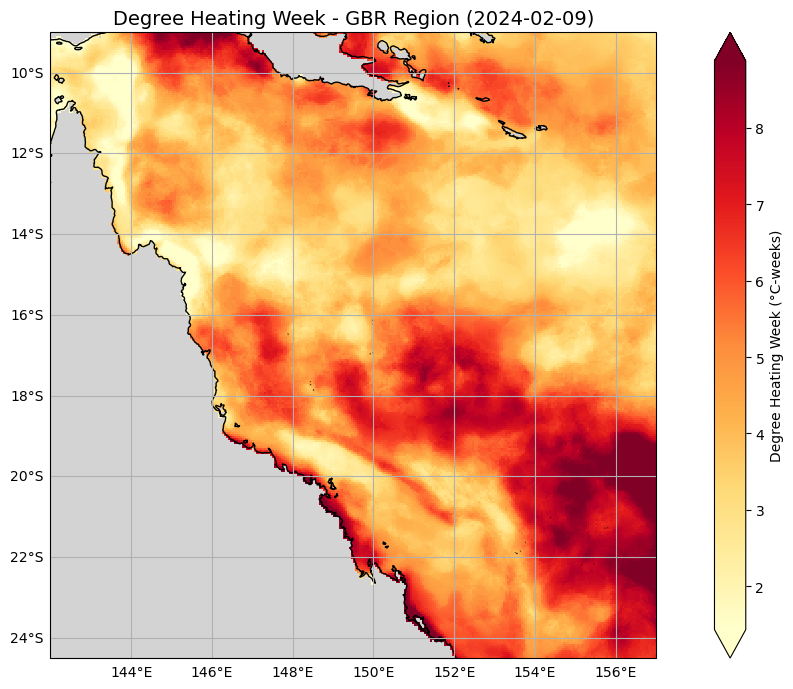

In [10]:
# PLOT A MAP

# ---------------------------------------------------------
# Choose the variable and time step to plot
# ---------------------------------------------------------
var_name = "degree_heating_week"
time_index = 2

data_to_plot = out_data[var_name].isel(time=time_index)

# Convert time to a readable date
plot_date = pd.to_datetime(out_data["time"].values[time_index]).strftime("%Y-%m-%d")

# ---------------------------------------------------------
# Define the map extent for the GBR region
# ---------------------------------------------------------
lon_min, lon_max = 142, 157
lat_min, lat_max = -24.5, -9

# ---------------------------------------------------------
# Create the map
# ---------------------------------------------------------
projection = ccrs.PlateCarree()

fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=projection)

# Plot the selected data
data_to_plot.plot(
    ax=ax,
    transform=projection,
    cmap="YlOrRd",
    robust=True,
    cbar_kwargs={"label": "Degree Heating Week (°C-weeks)"}
)

# ---------------------------------------------------------
# Add map features
# ---------------------------------------------------------
ax.coastlines(resolution="10m")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Set the region shown on the map
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=projection)

# ---------------------------------------------------------
# Add title and gridlines
# ---------------------------------------------------------
ax.set_title(f"Degree Heating Week - GBR Region ({plot_date})", fontsize=14)

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

plt.tight_layout()
plt.show()

Requested point:  lat=-23.0, lon=152.0
Nearest grid cell: lat=-22.975000381469727, lon=152.02499389648438


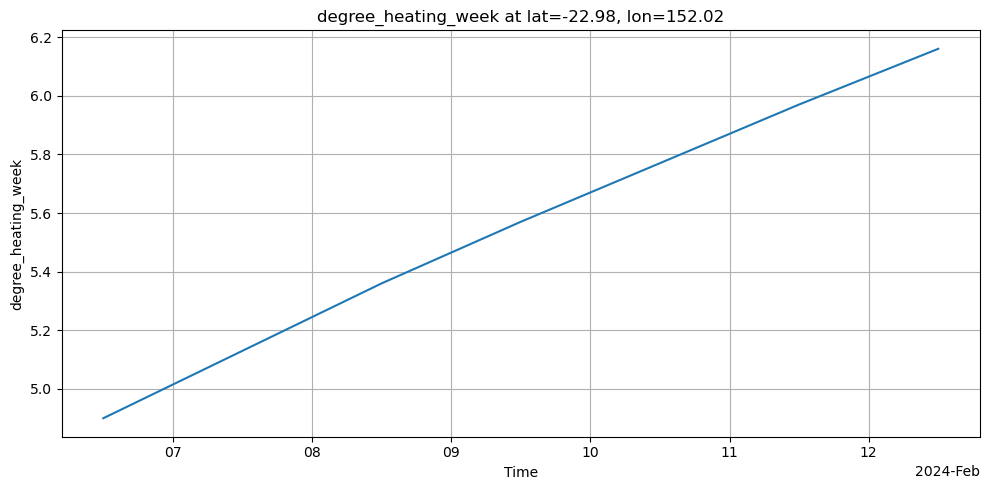

In [11]:
# PLOT LINE TIMESERIES

# ---------------------------------------------------------
# Choose variable and target point
# ---------------------------------------------------------
var_name = "degree_heating_week"
target_lat = -23.0
target_lon = 152.0

# ---------------------------------------------------------
# Detect coordinate names
# ---------------------------------------------------------
if "lat" in out_data.coords:
    lat_name = "lat"
elif "latitude" in out_data.coords:
    lat_name = "latitude"
else:
    raise ValueError("No latitude coordinate found.")

if "lon" in out_data.coords:
    lon_name = "lon"
elif "longitude" in out_data.coords:
    lon_name = "longitude"
else:
    raise ValueError("No longitude coordinate found.")

# ---------------------------------------------------------
# Extract nearest point time series
# ---------------------------------------------------------
point_ts = out_data[var_name].sel(
    {lat_name: target_lat, lon_name: target_lon},
    method="nearest"
)

selected_lat = float(point_ts[lat_name].values)
selected_lon = float(point_ts[lon_name].values)

print(f"Requested point:  lat={target_lat}, lon={target_lon}")
print(f"Nearest grid cell: lat={selected_lat}, lon={selected_lon}")

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
point_ts.plot(linewidth=1.5)

plt.title(f"{var_name} at lat={selected_lat:.2f}, lon={selected_lon:.2f}")
plt.xlabel("Time")
plt.ylabel(var_name)
plt.grid(True)
plt.tight_layout()
plt.show()

Requested point:  lat=-23.0, lon=152.0
Nearest grid cell: lat=-22.975000381469727, lon=152.02499389648438

Time range in extracted series:
2024-02-06 12:00:00 to 2024-02-12 12:00:00


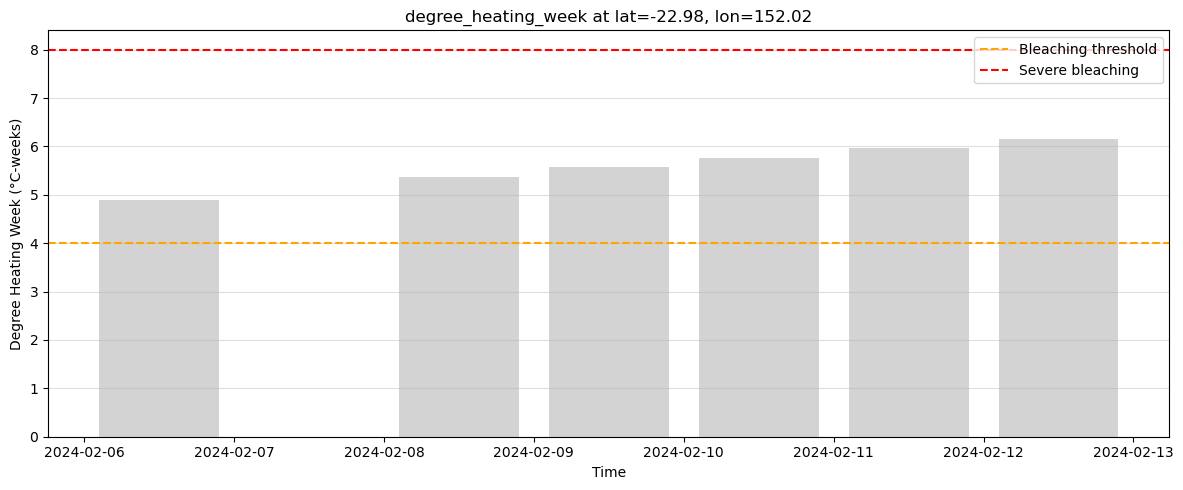

In [12]:
# PLOT BAR TIMESERIES

# ---------------------------------------------------------
# 1. Choose variable and target point
# ---------------------------------------------------------
var_name = "degree_heating_week"
target_lat = -23.0
target_lon = 152.0

# ---------------------------------------------------------
# 2. Detect coordinate names
# ---------------------------------------------------------
if "lat" in out_data.coords:
    lat_name = "lat"
elif "latitude" in out_data.coords:
    lat_name = "latitude"
else:
    raise ValueError("No latitude coordinate found.")

if "lon" in out_data.coords:
    lon_name = "lon"
elif "longitude" in out_data.coords:
    lon_name = "longitude"
else:
    raise ValueError("No longitude coordinate found.")

# ---------------------------------------------------------
# 3. Extract nearest point time series
# ---------------------------------------------------------
point_ts = out_data[var_name].sel(
    {lat_name: target_lat, lon_name: target_lon},
    method="nearest"
)

selected_lat = float(point_ts[lat_name].values)
selected_lon = float(point_ts[lon_name].values)

print(f"Requested point:  lat={target_lat}, lon={target_lon}")
print(f"Nearest grid cell: lat={selected_lat}, lon={selected_lon}")

# ---------------------------------------------------------
# 4. Convert time to datetime
# ---------------------------------------------------------
time_values = pd.to_datetime(point_ts["time"].values)
data_values = point_ts.values

print("\nTime range in extracted series:")
print(time_values.min(), "to", time_values.max())

# ---------------------------------------------------------
# 5. Plot as bars
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

plt.bar(
    time_values,
    data_values,
    width=0.8,   # good for daily data
    color="lightgrey",
    align="center"
)

# Thresholds
plt.axhline(4, color="orange", linestyle="--", label="Bleaching threshold")
plt.axhline(8, color="red", linestyle="--", label="Severe bleaching")

plt.title(f"{var_name} at lat={selected_lat:.2f}, lon={selected_lon:.2f}")
plt.xlabel("Time")
plt.ylabel("Degree Heating Week (°C-weeks)")
plt.grid(axis="y", alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

## End